# BOAMP Linkage Method Comparison Without Legal Ground Truth

This notebook compares the current calibrated BOAMP renewal-linking proxy-event definition with probabilistic and active-learning-assisted alternatives. The analysis is intentionally validation-oriented: BOAMP has no official renewal-chain ground truth, so real BOAMP events are treated as proxy recurrences, not formally verified renewal-chain labels.


## 1. Execute the Reproducible Analysis

The script below searches and loads the current project artifacts, builds the unified candidate-pair table, fits M1/M2, evaluates synthetic and real BOAMP behavior, selects broad/balanced/strict thresholds from observed grids, reruns the selected survival comparisons, writes all required tables, and prints a clear execution summary.


In [1]:
import runpy
import os
from pathlib import Path

cwd = Path.cwd()
project_root = cwd if (cwd / "scripts" / "linkage_method_comparison_no_ground_truth.py").exists() else cwd.parent
os.chdir(project_root)
runpy.run_path("scripts/linkage_method_comparison_no_ground_truth.py", run_name="__main__")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


=== BOAMP method-comparison execution summary ===
Files loaded: 12
  - boamp_renewal_linking_quality/outputs/boamp_renewal_candidates.csv
  - reports/tables/validation/calibrated_real_best_links_all_rules.csv
  - reports/tables/validation/calibrated_real_best_links_balanced.csv
  - reports/tables/validation/calibrated_real_best_links_broad.csv
  - reports/tables/validation/calibrated_real_best_links_strict.csv
  - data/synthetic/synthetic_boamp_true_links_all.csv
  - reports/tables/validation/synthetic_threshold_grid.csv
  - event_validation/outputs/manual_validation_audit_labeled.csv
  - data/processed/boamp_phase2_survival_calibrated_balanced.csv
  - reports/tables/survival/calibrated_rule_km_summary.csv
  - reports/tables/survival/calibrated_rule_cox_comparison.csv
  - reports/tables/survival/calibrated_balanced_aft_comparison.csv
Files created: 10
  - reports/tables/validation/unified_candidate_pair_table.csv
  - reports/tables/validation/linkage_method_comparison.csv
  - reports/

{'__name__': '__main__',
 '__doc__': None,
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': 'scripts/linkage_method_comparison_no_ground_truth.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <function __build_class__>,
  '__import__': <function __import__(name, globals=None, locals=None, fromlist

## 2. Files Loaded


In [2]:
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
inventory = pd.read_csv("reports/tables/validation/method_comparison_input_inventory.csv")
display(inventory)


,file_path,exists,modified_at,rows
0,boamp_renewal_linking_quality/outputs/boamp_renewal_candidates.csv,True,2026-07-06T15:10:16,3201
1,reports/tables/validation/calibrated_real_best_links_all_rules.csv,True,2026-07-06T15:15:26,838
2,reports/tables/validation/calibrated_real_best_links_balanced.csv,True,2026-07-06T15:15:26,269
3,reports/tables/validation/calibrated_real_best_links_broad.csv,True,2026-07-06T15:15:26,490
4,reports/tables/validation/calibrated_real_best_links_strict.csv,True,2026-07-06T15:15:26,79
5,data/synthetic/synthetic_boamp_true_links_all.csv,True,2026-07-06T15:12:49,4500
6,reports/tables/validation/synthetic_threshold_grid.csv,True,2026-07-06T15:14:09,4320
7,event_validation/outputs/manual_validation_audit_labeled.csv,True,2026-07-02T11:30:32,150
8,data/processed/boamp_phase2_survival_calibrated_balanced.csv,True,2026-07-06T15:15:26,1210
9,reports/tables/survival/calibrated_rule_km_summary.csv,True,2026-07-08T11:37:12,4


## 3. Unified Candidate-Pair Table


In [3]:
unified = pd.read_csv("reports/tables/validation/unified_candidate_pair_table.csv")
print(unified.shape)
display(unified.head())
display(unified.groupby("candidate_pair_dataset").size().rename("rows").reset_index())


(39939, 21)


,candidate_pair_dataset,scenario,source_contract_id,candidate_contract_id,buyer_key,text_similarity,cpv_score,generic_cpv_flag,temporal_score,time_gap_months,composite_score,rank,margin,buyer_frequency,missing_cpv_flag,missing_duration_flag,synthetic_true_match,negative_control,manual_audit_label,m1_match_probability,m2_match_probability
0,real_boamp,real_boamp,BOAMP:15-100455,BOAMP:19-156899,NAME:nantes metropole,0.4014,1.0,False,0.6557,50.07,0.6917,1,0.1355,72,False,False,NaN,False,NaN,0.898284,0.894734
1,real_boamp,real_boamp,BOAMP:15-100455,BOAMP:19-151382,NAME:nantes metropole,0.6307,0.0,True,0.7694,46.62,0.5562,2,NaN,72,False,False,NaN,True,NaN,0.721345,0.713441
2,real_boamp,real_boamp,BOAMP:15-100455,BOAMP:19-191665,NAME:nantes metropole,0.5054,0.0,False,0.8035,49.18,0.5129,3,NaN,72,False,False,NaN,True,NaN,0.295008,0.289670
3,real_boamp,real_boamp,BOAMP:15-100455,BOAMP:20-26585,NAME:nantes metropole,0.6166,0.0,False,0.4805,51.12,0.4928,4,NaN,72,False,False,NaN,True,NaN,0.290396,0.288022
4,real_boamp,real_boamp,BOAMP:15-100455,BOAMP:20-11000,NAME:nantes metropole,0.5304,0.0,True,0.6393,50.16,0.4900,5,NaN,72,False,False,NaN,True,NaN,0.538326,0.528878


,candidate_pair_dataset,rows
0,real_boamp,3201
1,synthetic,36738


## 4. Method Comparison Outputs


In [4]:
real_comparison = pd.read_csv("reports/tables/validation/linkage_method_comparison.csv")
synthetic_comparison = pd.read_csv("reports/tables/validation/linkage_method_comparison_synthetic_metrics.csv")
probabilistic = pd.read_csv("reports/tables/validation/probabilistic_linkage_results.csv")
recommendation = pd.read_csv("reports/tables/validation/final_method_recommendation.csv")

display(real_comparison)
display(synthetic_comparison[synthetic_comparison["scenario"].isin(["all", "easy", "medium", "hard"])])
display(probabilistic)
display(recommendation)


,method,variant,event_count,eligible_source_count,event_rate,median_text_similarity,median_composite_score,median_margin,generic_cpv_share,negative_control_acceptance_rate,manual_audit_decided_n,manual_audit_precision,manual_audit_coverage_of_links,manual_audit_role,events_available_for_survival
0,M0,balanced,269,1210,0.222314,0.62910,0.624293,0.048160,0.230483,0.094243,32,0.437500,0.118959,diagnostic_only_baseline_selected_sample,269
1,M0,broad,490,1210,0.404959,0.52985,0.551040,0.055187,0.240816,0.416009,56,0.250000,0.114286,diagnostic_only_baseline_selected_sample,490
2,M0,strict,79,1210,0.065289,0.84650,0.806213,0.031880,0.164557,0.003549,14,0.857143,0.177215,diagnostic_only_baseline_selected_sample,79
3,M1,balanced,256,1210,0.211570,0.61850,0.662500,0.157200,0.371094,0.084779,35,0.371429,0.136719,diagnostic_only_baseline_selected_sample,256
4,M1,broad,664,1210,0.548760,0.46470,0.517450,0.084450,0.310241,0.955442,77,0.168831,0.115964,diagnostic_only_baseline_selected_sample,664
5,M1,strict,92,1210,0.076033,0.79660,0.810750,0.279900,0.293478,0.009858,20,0.550000,0.217391,diagnostic_only_baseline_selected_sample,92
6,M2,balanced,254,1210,0.209917,0.61950,0.665250,0.157900,0.370079,0.078864,35,0.371429,0.137795,diagnostic_only_baseline_selected_sample,254
7,M2,broad,664,1210,0.548760,0.46425,0.517250,0.086900,0.308735,0.952681,77,0.168831,0.115964,diagnostic_only_baseline_selected_sample,664
8,M2,strict,92,1210,0.076033,0.79660,0.810750,0.279900,0.293478,0.009858,20,0.550000,0.217391,diagnostic_only_baseline_selected_sample,92


,method,variant,scenario,TP,FP,FN,TN,precision,recall,F1,event_count,event_rate,median_text_similarity,median_composite_score,median_margin,generic_cpv_share
0,M0,broad,easy,655,316,112,461,0.674562,0.853977,0.753740,971,0.647333,0.780713,0.814881,0.193334,0.113285
1,M0,broad,medium,520,535,238,343,0.492891,0.686016,0.573635,1055,0.703333,0.583106,0.690785,0.121097,0.161137
2,M0,broad,hard,283,753,452,313,0.273166,0.385034,0.319593,1036,0.690667,0.555690,0.651064,0.086819,0.208494
3,M0,broad,all,1458,1604,802,1117,0.476159,0.645133,0.547914,3062,0.680444,NaN,NaN,NaN,0.160972
6,M0,balanced,easy,618,177,149,589,0.777358,0.805737,0.791293,795,0.530000,0.836358,0.857887,0.153423,0.105660
7,M0,balanced,medium,444,295,314,544,0.600812,0.585752,0.593186,739,0.492667,0.708960,0.736728,0.099343,0.132612
8,M0,balanced,hard,222,477,513,485,0.317597,0.302041,0.309623,699,0.466000,0.616443,0.687365,0.066491,0.188841
9,M0,balanced,all,1284,949,976,1618,0.575011,0.568142,0.571556,2233,0.496222,NaN,NaN,NaN,0.142371
12,M0,strict,easy,505,65,262,685,0.885965,0.658409,0.755423,570,0.380000,0.881179,0.895107,0.166735,0.092982
13,M0,strict,medium,259,64,499,707,0.801858,0.341689,0.479186,323,0.215333,0.877040,0.844181,0.091625,0.102167


,method,variant,selection_score,threshold,text_threshold,composite_threshold,margin_threshold,W,generic_cpv_rule,selection_basis
0,M0,broad,NaN,none,0.4,none,none,6,generic_corrected,Current calibrated reference rule M0 from recommended_event_rules.csv.
1,M0,balanced,NaN,0.5,0.5,0.5,none,6,generic_corrected,Current calibrated reference rule M0 from recommended_event_rules.csv.
2,M0,strict,NaN,0.65,0.7,0.65,none,6,generic_corrected,Current calibrated reference rule M0 from recommended_event_rules.csv.
3,M1,broad,NaN,0.05,NaN,NaN,NaN,6,corrected_generic_cpv_features,"Selected from observed probability-threshold grid using synthetic precision/recall, negative controls, real BOAMP event count, manual audit labels when avai..."
4,M1,balanced,0.795515,0.65,NaN,NaN,NaN,6,corrected_generic_cpv_features,"Selected from observed probability-threshold grid using synthetic precision/recall, negative controls, real BOAMP event count, manual audit labels when avai..."
5,M1,strict,NaN,0.95,NaN,NaN,NaN,6,corrected_generic_cpv_features,"Selected from observed probability-threshold grid using synthetic precision/recall, negative controls, real BOAMP event count, manual audit labels when avai..."
6,M2,broad,NaN,0.05,NaN,NaN,NaN,6,corrected_generic_cpv_features,"Selected from observed probability-threshold grid using synthetic precision/recall, negative controls, real BOAMP event count, manual audit labels when avai..."
7,M2,balanced,0.796994,0.65,NaN,NaN,NaN,6,corrected_generic_cpv_features,"Selected from observed probability-threshold grid using synthetic precision/recall, negative controls, real BOAMP event count, manual audit labels when avai..."
8,M2,strict,NaN,0.95,NaN,NaN,NaN,6,corrected_generic_cpv_features,"Selected from observed probability-threshold grid using synthetic precision/recall, negative controls, real BOAMP event count, manual audit labels when avai..."


,selected_method,selected_variant,recommendation,reference_method,best_alternative_method,best_alternative_variant,m0_role,best_alternative_role,m0_balanced_score,best_alternative_score,benchmark_preferred_method,m0_synthetic_real_text_shift,best_alternative_synthetic_real_text_shift,text_similarity_backend,criterion_score_exceeds_m0_by_margin,criterion_negative_control_not_worse_than_m0,criterion_event_count_sufficient_for_survival,criterion_synthetic_real_profile_shift_acceptable,criterion_same_text_backend_as_real_pipeline,manual_audit_role,language_note
0,M2,balanced,promote_m2_balanced_to_main_method,M0 calibrated balanced composite rule,M2,balanced,conservative_baseline_sensitivity,main_method_benchmark_preferred,0.740978,0.796994,M2,0.128252,0.04475,sentence_transformers,True,True,True,True,True,"Diagnostic only: the 150-case audit sample was stratified on the pre-calibration baseline's own links and confidence tiers, so mapped audit precision is bas...","Real BOAMP event labels remain proxy recurrences: identifiable reappearances of similar procurement needs, not formally verified renewal chains. Real precis..."


## 5. Active-Learning Review Sample


In [5]:
active_sample = pd.read_csv("reports/tables/validation/active_learning_review_sample.csv")
print(active_sample.shape)
display(active_sample.head(20))
display(active_sample["review_reason"].value_counts().rename("n_pairs").reset_index())


(150, 22)


,review_reason,priority_score,source_contract_id,candidate_contract_id,buyer_key,text_similarity,cpv_score,generic_cpv_flag,temporal_score,time_gap_months,composite_score,rank,margin,manual_audit_label,m1_match_probability,m2_match_probability,src_objet,cand_objet,src_cpv,cand_cpv,source_start_date,candidate_start_date
0,event0_high_nearest_candidate,2.3212,BOAMP:22-39212,BOAMP:23-144303,NAME:nantes metropole,0.6476,0.2,True,0.1811,19.09,0.4953,1,0.0217,NaN,0.648531,0.637512,"prestations de conception, développement, intégration, formation et maintenance de sites web pour la ville de nantes, son ccas et nantes métropole règlement",tierce maintenance applicative de la plateforme eservices et du compte nantes métropole pour les besoins du groupement de commandes informatiques (nantes mé...,72413000.0,72000000.0,2022-03-18,2023-10-20
1,event0_high_nearest_candidate,2.3060,BOAMP:18-90097,BOAMP:24-90280,NAME:nantes metropole,0.6470,0.0,True,0.3506,63.90,0.4789,1,0.0199,NaN,0.514927,0.503058,acquisition et mise en oeuvre d'une solution logicielle de gestion de l'occupation du domaine public,Prestations en appui de la conduite de projets en systèmes d'informations ressources humaines,48000000.0,72250000.0,2019-04-05,2024-08-01
2,event0_high_nearest_candidate,2.2042,BOAMP:16-79523,BOAMP:17-100105,SIREN:214401846,0.5297,0.0,True,0.5878,9.53,0.4794,1,0.0049,NaN,0.543753,0.526852,acquisition de materiels informatiques et logiciels,17s0056 - renouvellement des infrastructures de stockage informatique,30230000.0,48000000.0,2016-10-03,2017-07-20
3,event0_high_nearest_candidate,2.1354,BOAMP:19-53794,BOAMP:23-106776,SIREN:224900019,0.4837,0.2,True,0.3820,51.71,0.4699,1,0.0182,NaN,0.618193,0.603383,"fourniture d'un logiciel de gestion électronique du courrier, prestations de mise en oeuvre associées et maintenance",Fourniture d'un logiciel de gestion de photothèque en mode SaaS et prestations associées,48000000.0,48311000.0,2019-04-05,2023-07-27
4,event0_high_nearest_candidate,2.0792,BOAMP:19-15670,BOAMP:23-61217,NAME:ctre hosp universitaire angers,0.4194,0.2,True,0.5339,45.20,0.4745,1,0.0147,NaN,0.594585,0.577505,La location en mode SaaS (logiciel en tant que service) d'un logiciel de gestion des plannings médicaux ainsi que toutes les prestations nécessaires à sa mi...,"Accord-cadre conception, développement, maintenance de sites WEB, Intranet et plan interactif GHT49",72000000.0,72413000.0,2019-07-30,2023-05-06
5,event0_high_nearest_candidate,2.0789,BOAMP:17-123450,BOAMP:21-77546,SIREN:935367433,0.5937,0.0,False,0.5339,45.20,0.4943,1,0.0091,NaN,0.312178,0.302849,"Fourniture, mise en uvre, maintenance et évolution d'une solution d'infrastructure pour le système d'information du Département.",Prestations d'assistance et d'expertise autour des composants d'infrastructure de niveau 2 et 3 pour le Département et les collèges de Loire-Atlantique,48822000.0,72611000.0,2017-09-03,2021-06-10
6,event0_high_nearest_candidate,2.0782,BOAMP:18-80158,BOAMP:19-56876,SIREN:935367433,0.4456,0.0,True,0.6535,9.92,0.4589,1,0.0263,NaN,0.508368,0.491476,Prestations d'assistance à maîtrise d'ouvrage et maîtrise d'oeuvre de développement numérique,Marchés de travaux pour la rénovation du musée Dobrée à Nantes,72600000.0,45000000.0,2018-06-13,2019-04-11
7,event0_high_nearest_candidate,2.0717,BOAMP:22-29878,BOAMP:23-104062,SIREN:234400034,0.3845,0.0,True,0.9358,12.39,0.4910,1,0.0038,NaN,0.419199,0.399501,SYSTEME D'INFORMATION DU PATRIMOINE IMMOBILIER FOURNITURE D'UNE SOLUTION DE GESTION TECHNIQUE DU PATRIMOINE IMMOBILIER POUR LA REGION DES PAYS DE LA LOIRE,REFONTE ET MAINTENANCE ASSOCIEE DES INSTALLATIONS AUDIOVISUELLES DU CAMPUS ET DES MAISONS DE LA REGION DES PAYS DE LA LOIRE,48000000.0,32321300.0,2022-07-11,2023-07-23
8,event0_high_nearest_candidate,2.0613,BOAMP:19-32405,BOAMP:20-12202,SIREN:234400034,0.3868,0.0,True,0.9163,11.50,0.4880,1,0.0135,NaN,0.421146,0.402231,Conception et acquisition de gilets haute visibilité normalisés à destination des élèves emprunta

,review_reason,n_pairs
0,event0_high_nearest_candidate,25
1,high_score_generic_cpv,25
2,high_text_cpv_mismatch,25
3,low_top1_top2_margin,25
4,near_m0_threshold,25
5,same_buyer_same_cpv_weak_text,25


## 6. Survival Comparison


In [6]:
survival = pd.read_csv("reports/tables/validation/method_survival_comparison.csv")
display(survival)


,method,variant,n,events,event_rate,km_median_months,km_median_reached,survival_12m,survival_24m,survival_48m,survival_60m,cox_c_index,best_aft_model,best_aft_aic,aft_models_fit,survival_dataset,operational_risk_indicators_available,risk_indicator_rows,median_p_renewal_12m,median_p_renewal_24m
0,M0,balanced,1210,269,0.222314,inf,False,0.959326,0.922993,0.832499,0.751797,0.544208,LogNormalAFT,3542.540041,WeibullAFT:3570.18; LogNormalAFT:3542.54; LogLogisticAFT:3579.97,data/processed/boamp_phase2_survival_method_m0_balanced.csv,True,1204,0.0198,0.0624
1,M2,balanced,1210,254,0.209917,inf,False,0.955835,0.920670,0.840125,0.759505,0.553402,LogNormalAFT,3357.886656,WeibullAFT:3390.56; LogNormalAFT:3357.89; LogLogisticAFT:3392.03,data/processed/boamp_phase2_survival_method_m2_balanced.csv,True,1204,0.0206,0.0634
2,M0,strict,1210,79,0.065289,inf,False,0.989887,0.981047,0.954612,0.916330,0.538096,LogNormalAFT,1242.829380,WeibullAFT:1245.37; LogNormalAFT:1242.83; LogLogisticAFT:1253.32,data/processed/boamp_phase2_survival_method_m0_strict.csv,False,0,NaN,NaN


## 7. Figures


reports/figures/validation/method_comparison_synthetic_precision_recall.png


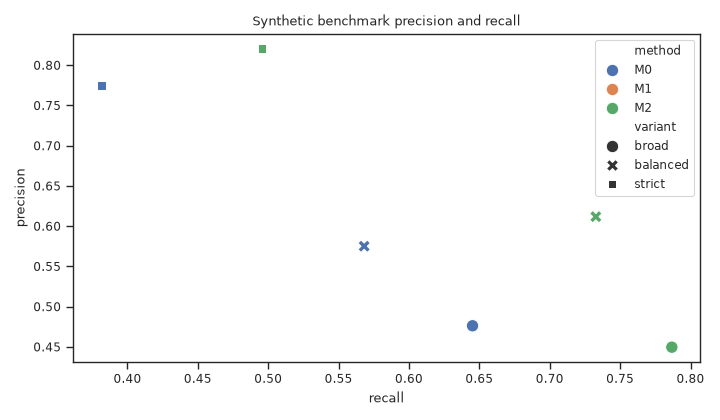

reports/figures/validation/method_comparison_real_event_counts.png


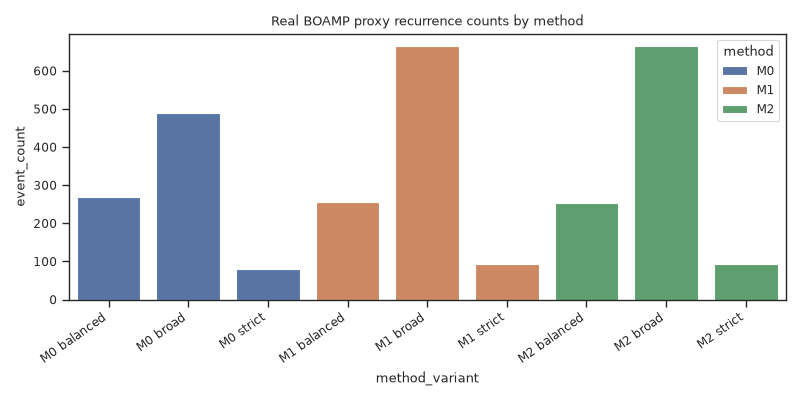

reports/figures/validation/method_survival_km_probabilities.png


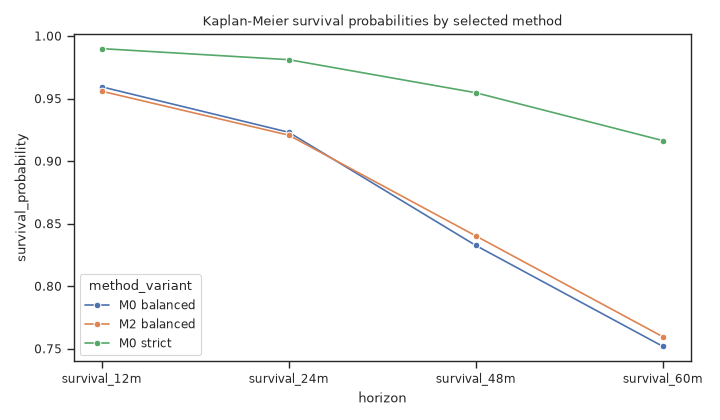

In [7]:
from IPython.display import Image, display
for fig in [
    "reports/figures/validation/method_comparison_synthetic_precision_recall.png",
    "reports/figures/validation/method_comparison_real_event_counts.png",
    "reports/figures/validation/method_survival_km_probabilities.png",
]:
    print(fig)
    display(Image(filename=fig))


## Final Executed Summary

### Why these methods were tested

BOAMP does not provide official renewal-chain ground truth, so the comparison treats the observed event as a proxy recurrence: an identifiable reappearance of a similar procurement need under a transparent matching rule. The goal is not to claim known real BOAMP precision or recall. The goal is to compare the current calibrated rule against literature-supported alternatives using synthetic truth, negative controls, manual audit evidence where available, and survival-model sufficiency.

### Methods and literature ideas

- M0: calibrated deterministic composite rule. This corresponds to rule-based record linkage with domain-engineered similarity scores and threshold calibration.
- M1: probabilistic linkage classifier. This follows the Fellegi-Sunter/probabilistic linkage idea, implemented here as a logistic match-probability model because Splink and recordlinkage were not available in the current environment.
- M2: active-learning-assisted linkage. This uses the same probabilistic feature space but incorporates mapped manual TP/FP accepted-link labels and exports a targeted review sample for uncertain or high-risk candidate pairs.

### Actual computed results

Real BOAMP event counts:
- method: M0; variant: balanced; events: 269; event_rate: 0.22231404958677686
- method: M0; variant: broad; events: 490; event_rate: 0.4049586776859504
- method: M0; variant: strict; events: 79; event_rate: 0.0652892561983471
- method: M1; variant: balanced; events: 256; event_rate: 0.2115702479338843
- method: M1; variant: broad; events: 664; event_rate: 0.5487603305785124
- method: M1; variant: strict; events: 92; event_rate: 0.07603305785123966
- method: M2; variant: balanced; events: 254; event_rate: 0.20991735537190082
- method: M2; variant: broad; events: 664; event_rate: 0.5487603305785124
- method: M2; variant: strict; events: 92; event_rate: 0.07603305785123966

Synthetic benchmark metrics across all scenarios:
- method: M0; variant: broad; precision: 0.4761593729588504; recall: 0.6451327433628319; FP: 1604; FN: 802
- method: M0; variant: balanced; precision: 0.5750111957008509; recall: 0.5681415929203539; FP: 949; FN: 976
- method: M0; variant: strict; precision: 0.7751798561151079; recall: 0.38141592920353984; FP: 250; FN: 1398
- method: M1; variant: broad; precision: 0.4495575221238938; recall: 0.7867256637168142; FP: 2177; FN: 482
- method: M1; variant: balanced; precision: 0.6117473217584042; recall: 0.7327433628318584; FP: 1051; FN: 604
- method: M1; variant: strict; precision: 0.8205128205128205; recall: 0.49557522123893805; FP: 245; FN: 1140
- method: M2; variant: broad; precision: 0.4495575221238938; recall: 0.7867256637168142; FP: 2177; FN: 482
- method: M2; variant: balanced; precision: 0.6117473217584042; recall: 0.7327433628318584; FP: 1051; FN: 604
- method: M2; variant: strict; precision: 0.8205128205128205; recall: 0.49557522123893805; FP: 245; FN: 1140

Survival results for the required selected runs:
- method: M0; variant: balanced; events: 269; S12: 0.9593262418851396; S24: 0.9229928714737403; S48: 0.8324989827689695; S60: 0.7517968179148288; KM median reached: False; Cox C-index: 0.5442076079295669; best AFT: LogNormalAFT
- method: M2; variant: balanced; events: 254; S12: 0.955835208475405; S24: 0.9206697976230506; S48: 0.8401250301747325; S60: 0.759505407906109; KM median reached: False; Cox C-index: 0.553401633996557; best AFT: LogNormalAFT
- method: M0; variant: strict; events: 79; S12: 0.9898866360714502; S24: 0.9810471724008155; S48: 0.954612485098655; S60: 0.9163296472815944; KM median reached: False; Cox C-index: 0.5380956275215353; best AFT: LogNormalAFT

Selected thresholds:
- method: M0; variant: broad; threshold: none; text_threshold: 0.4; composite_threshold: none; margin_threshold: none
- method: M0; variant: balanced; threshold: 0.5; text_threshold: 0.5; composite_threshold: 0.5; margin_threshold: none
- method: M0; variant: strict; threshold: 0.65; text_threshold: 0.7; composite_threshold: 0.65; margin_threshold: none
- method: M1; variant: broad; threshold: 0.05; text_threshold: nan; composite_threshold: nan; margin_threshold: nan
- method: M1; variant: balanced; threshold: 0.65; text_threshold: nan; composite_threshold: nan; margin_threshold: nan
- method: M1; variant: strict; threshold: 0.95; text_threshold: nan; composite_threshold: nan; margin_threshold: nan
- method: M2; variant: broad; threshold: 0.05; text_threshold: nan; composite_threshold: nan; margin_threshold: nan
- method: M2; variant: balanced; threshold: 0.65; text_threshold: nan; composite_threshold: nan; margin_threshold: nan
- method: M2; variant: strict; threshold: 0.95; text_threshold: nan; composite_threshold: nan; margin_threshold: nan

### Decision logic and the manual-audit bias caveat

The final selection deliberately does **not** use mapped manual-audit precision as a decision criterion. The 150-case audit sample (`event_validation/scripts/build_validation_sample.py`) was stratified on the **pre-calibration baseline's own links**, event flags, score margins, and confidence tiers, so the audited pairs are baseline-anchored: each method's mapped audit precision is computed only on the small subset of its links that coincide with baseline-audited pairs (roughly 32-35 decided pairs per balanced variant, 12-14% coverage). That makes it a plausibility diagnostic, not an independent validation set for comparing M0, M1, and M2.

Instead, the selection score combines only method-neutral evidence: benchmark-estimated precision and recall (synthetic pairs scored with the **same Sentence-Transformer encoder as the real pipeline**), real-data negative-control acceptance, and survival event sufficiency. An alternative is promoted over M0 balanced only if it passes every promotion criterion (score margin, negative controls not worse, enough events, acceptable synthetic-to-real accepted-link profile shift, and same text backend as the real pipeline).

Result: **promote_m2_balanced_to_main_method** — benchmark-preferred method: M2; M0 role: conservative_baseline_sensitivity; alternative role: main_method_benchmark_preferred.

Promotion criteria: score_exceeds_m0_by_margin=PASS; negative_control_not_worse_than_m0=PASS; event_count_sufficient_for_survival=PASS; synthetic_real_profile_shift_acceptable=PASS; same_text_backend_as_real_pipeline=PASS.

### Limitations

- Real BOAMP precision and recall are not directly observable; only synthetic benchmark precision/recall are, and they describe a controlled BOAMP-like benchmark, not real BOAMP truth.
- The mapped manual audit is baseline-biased (see above) and is reported as a diagnostic only.
- M1 and M2 use a logistic probability model because Splink and recordlinkage were unavailable.
- M2 additionally trains on the mapped manual TP/FP labels (weighted); because those labels come from the baseline-anchored audit, M1 (which never touches them) is the cleaner check — M1 balanced shows nearly identical gains, so the promotion does not hinge on the audit labels.
- M1/M2 thresholds are chosen on the same synthetic grid used for evaluation (mild optimism, symmetric with M0's calibration on the same benchmark).
- AFT AIC values are not comparable across event definitions (different event sets imply different likelihood scales).
- The active-learning review sample is a prioritization output, not a completed validation result.

### Outputs generated

- reports/tables/validation/unified_candidate_pair_table.csv
- reports/tables/validation/linkage_method_comparison.csv
- reports/tables/validation/linkage_method_comparison_synthetic_metrics.csv
- reports/tables/validation/active_learning_review_sample.csv
- reports/tables/validation/probabilistic_linkage_results.csv
- reports/tables/validation/final_method_recommendation.csv
- reports/tables/validation/method_survival_comparison.csv
- reports/figures/validation/method_comparison_synthetic_precision_recall.png
- reports/figures/validation/method_comparison_real_event_counts.png
- reports/figures/validation/method_survival_km_probabilities.png

### Report updates needed

- Present the selected main method and roles exactly as computed above (selected method, benchmark-preferred method, conservative baseline).
- Explain that mapped audit precision is a baseline-biased diagnostic and was excluded from the selection score.
- Report synthetic precision and recall separately, not only F1.
- Report real BOAMP event counts, negative-control behavior, manual audit precision where available, and survival sufficiency without claiming known real precision/recall.
- Keep the language as proxy recurrence or identifiable reappearance of a similar procurement need, not as a formally verified renewal chain.
